# Battery Health — Exploratory Data Analysis

Datasets: NASA PCoE Li-ion Battery Aging (controlled + randomized)

| Group | Batteries | Condition |
|---|---|---|
| Baseline | B0005–B0007, B0018 | Room temp, fixed discharge |
| Hot | B0029–B0032 | 43 °C, 4 A constant |
| Cold | B0042–B0044 | 4 °C, mixed loads (B0041 excluded — see §2a) |
| Renewable proxy | RW1, RW2, RW9 | Random-walk current, room temp |
| Skewed-high load | RW17–RW20 | High-current skew, room temp |
| Skewed-low load | RW13–RW16 | Low-current skew, room temp |

## 1. Imports & paths

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
from src.battery import (
    load_controlled, cycles_to_df,
    load_randomized, rw_steps_to_df,
    load_impedance, attach_impedance,
    dcir_proxy_controlled,
    compute_rul, engineer_features,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="tab10")

DATA = Path("../data")
CTRL = DATA / "controlled"
RW   = DATA / "randomized"
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)


## 2. Loading helpers

### 2a. Controlled (`.mat` → `cycle[]` struct)

**Data cleaning decisions:**

- **Capacity baseline** — set to the max over the first 10 % of cycles (not cycle 0). Li-ion batteries at 43 °C show an initial capacity rise before permanent fade; using cycle 0 as baseline would put retention above 1.0 early in life.
- **Partial-discharge filter** — cycles with capacity < 50 % of baseline are dropped. The NASA README for B0041–B0044 documents occasional anomalously short discharges with no identified cause.
- **Cold batteries: mixed discharge rates** — B0042–B0044 interleave 1 A and 4 A discharge cycles. At 4 °C the Peukert effect is significant, so the two rates yield different apparent capacities for the same state of health. Keeping both would produce a sawtooth degradation curve. Only cycles with inferred avg current ≥ 1.8 A (the 4 A primary protocol) are kept, making cold batteries comparable to the hot group.
- **B0041 excluded** — only 25 cycles (vs. 66–100 for the other cold batteries), starting capacity 1.33 Ahr (vs. ~1.73 Ahr), and flagged anomalous in the NASA README. Not enough clean data to be useful.

In [2]:
# Functions moved to src/battery.py — imported above.
# Data cleaning rationale documented in §2a markdown above.


### 2b. Randomized (`.mat` → `step[]` struct)

Capacity is not pre-computed. It is derived by integrating current over **reference discharge steps** (type `'D'`, comment contains `'reference'`) inserted every ~50 random-walk cycles.

**Data cleaning decisions:**

- **OCV sweep removed** — each reference block starts with a 0.04 A low-current sweep; filtered out by requiring mean |I| > 0.5 A.
- **Pulsed sub-step removed** — each reference block ends with a 1 A × 10 min pulsed discharge (~600 s); filtered out by requiring step duration > 1200 s.
- **Partial-recovery discharge removed** — after the main 2 A reference discharge, the battery rests briefly then undergoes a second discharge from the partially recovered state. Both steps pass the current and duration filters but the second yields ~20–25 % less capacity, producing a sawtooth. Since even-indexed steps are always the full-charge → discharge reference and odd-indexed steps are always the partial-recovery discharge, we keep `iloc[::2]`.

In [3]:
# Functions moved to src/battery.py — imported above.
# Data cleaning rationale documented in §2b markdown above.


## 3. Load all controlled batteries

In [4]:
G1 = CTRL / "1. BatteryAgingARC-FY08Q4"
G3 = CTRL / "3. BatteryAgingARC_25-44"

# (battery_id, cutoff_v, temp_condition, path)
CONTROLLED_BATTERIES = [
    # Baseline — room temp
    ("B0005", 2.7, "room", G1 / "B0005.mat"),
    ("B0006", 2.5, "room", G1 / "B0006.mat"),
    ("B0007", 2.2, "room", G1 / "B0007.mat"),
    ("B0018", 2.5, "room", G1 / "B0018.mat"),
    # Hot — 43 °C
    ("B0029", 2.0, "hot",  G3 / "B0029.mat"),
    ("B0030", 2.2, "hot",  G3 / "B0030.mat"),
    ("B0031", 2.5, "hot",  G3 / "B0031.mat"),
    ("B0032", 2.7, "hot",  G3 / "B0032.mat"),
    # Cold — 4 °C (B0041 dropped: documented anomalous per NASA README, only 25 cycles, atypical starting capacity)
    ("B0042", 2.2, "cold", G3 / "B0042.mat"),
    ("B0043", 2.5, "cold", G3 / "B0043.mat"),
    ("B0044", 2.7, "cold", G3 / "B0044.mat"),
]

ctrl_dfs = []
for battery_id, cutoff_v, temp_cond, path in CONTROLLED_BATTERIES:
    cycles = load_controlled(path)
    df = cycles_to_df(cycles, battery_id, cutoff_v, temp_cond)
    ctrl_dfs.append(df)
    print(f"{battery_id} ({temp_cond:4s}): {len(df):3d} cycles | "
          f"C0={df['capacity_ahr'].iloc[0]:.3f} Ahr → "
          f"C_end={df['capacity_ahr'].iloc[-1]:.3f} Ahr")

controlled = pd.concat(ctrl_dfs, ignore_index=True)
controlled.head()

B0005 (room): 168 cycles | C0=1.862 Ahr → C_end=1.328 Ahr
B0006 (room): 168 cycles | C0=2.047 Ahr → C_end=1.205 Ahr
B0007 (room): 168 cycles | C0=1.919 Ahr → C_end=1.457 Ahr


B0018 (room): 132 cycles | C0=1.868 Ahr → C_end=1.361 Ahr
B0029 (hot ):  40 cycles | C0=1.741 Ahr → C_end=1.655 Ahr
B0030 (hot ):  40 cycles | C0=1.703 Ahr → C_end=1.594 Ahr
B0031 (hot ):  40 cycles | C0=1.682 Ahr → C_end=1.680 Ahr
B0032 (hot ):  40 cycles | C0=1.710 Ahr → C_end=1.642 Ahr
B0042 (cold):  75 cycles | C0=1.769 Ahr → C_end=0.889 Ahr
B0043 (cold):  41 cycles | C0=1.732 Ahr → C_end=1.486 Ahr
B0044 (cold):  30 cycles | C0=1.689 Ahr → C_end=1.488 Ahr


,battery_id,cutoff_v,temp_condition,cycle_index,timestamp,ambient_temp,capacity_ahr,r_proxy,voltage_min,voltage_mean,temp_mean,temp_max,duration_s,avg_current_a,rul,capacity_retention,_baseline
0,B0005,2.7,room,0,1.207143e+09,24.0,1.862203,0.164671,2.612467,3.529829,32.572328,38.982181,3690.234,1.816668,1.000000,1.000000,1.862203
1,B0005,2.7,room,1,1.207158e+09,24.0,1.852078,0.160306,2.587209,3.537320,32.725235,39.033398,3672.344,1.815592,0.994012,0.994563,1.862203
2,B0005,2.7,room,2,1.207174e+09,24.0,1.841049,0.158295,2.651917,3.543737,32.642862,38.818797,3651.641,1.815013,0.988024,0.988640,1.862203
3,B0005,2.7,room,3,1.207189e+09,24.0,1.840912,0.157266,2.592948,3.543666,32.514876,38.762305,3631.563,1.824912,0.982036,0.988567,1.862203
4,B0005,2.7,room,4,1.207204e+09,24.0,1.840360,0.156728,2.547420,3.542343,32.382349,38.665393,3629.172,1.825567,0.976048,0.988270,1.862203


## 3a. Trapezoid integration accuracy check

**Decision:** we always compute capacity via `∫|I| dt / 3600` rather than the pre-computed `Capacity` field in the `.mat` files.  
**Why:** the stored field is only populated for 2.7 V-cutoff cycles; all other cutoffs must be integrated anyway, so we use a single consistent method.  
**Validation below:** compare trapezoid result against the stored value on the 2.7 V-cutoff batteries (B0005, B0032, B0044) where both exist.

In [5]:
from src.battery import load_controlled

_validation_rows = []
for bat_id, cutoff_v, path in [
    ("B0005", 2.7, CTRL / "1. BatteryAgingARC-FY08Q4" / "B0005.mat"),
    ("B0032", 2.7, CTRL / "3. BatteryAgingARC_25-44"  / "B0032.mat"),
    ("B0044", 2.7, CTRL / "3. BatteryAgingARC_25-44"  / "B0044.mat"),
]:
    for c in load_controlled(path):
        if c["type"] != "discharge":
            continue
        d = c["data"]
        stored = d.get("Capacity")
        if stored is None or float(stored) == 0:
            continue
        t = np.asarray(d["Time"],             dtype=float)
        I = np.asarray(d["Current_measured"], dtype=float)
        trapz_val = float(np.trapezoid(np.abs(I), t) / 3600)
        _validation_rows.append({
            "battery_id":  bat_id,
            "stored_Ahr":  float(stored),
            "trapz_Ahr":   trapz_val,
            "abs_err_Ahr": abs(trapz_val - float(stored)),
            "pct_err":     abs(trapz_val - float(stored)) / float(stored) * 100,
        })

_val_df = pd.DataFrame(_validation_rows)
summary = (
    _val_df.groupby("battery_id")[["abs_err_Ahr", "pct_err"]]
    .agg(["mean", "max"])
    .round(4)
)
print("Trapezoid vs stored Capacity (2.7 V-cutoff batteries only)")
display(summary)
print(f"\nOverall mean error: {_val_df.pct_err.mean():.3f}%  |  max: {_val_df.pct_err.max():.3f}%")


Trapezoid vs stored Capacity (2.7 V-cutoff batteries only)


abs_err_Ahr         pct_err         
                  mean     max    mean      max
battery_id                                     
B0005           0.0034  0.0058  0.2127   0.3176
B0032           0.0044  0.0064  0.2556   0.3886
B0044           0.0044  0.0072  4.7001  12.0359


Overall mean error: 1.780%  |  max: 12.036%


## 4. Load all randomized batteries

In [6]:
RW_UNI_VAR  = RW / "Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post" / "data" / "Matlab"
RW_UNI_CD   = RW / "Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post"          / "data" / "Matlab"
RW_SKW_LOW  = RW / "RW_Skewed_Low_Room_Temp_DataSet_2Post"                                / "data" / "Matlab"
RW_SKW_HIGH = RW / "RW_Skewed_High_Room_Temp_DataSet_2Post"                               / "data" / "Matlab"

# (battery_id, rw_condition, path)
RW_BATTERIES = [
    # Renewable proxy
    ("RW1",  "uniform_var_charge", RW_UNI_VAR  / "RW1.mat"),
    ("RW2",  "uniform_var_charge", RW_UNI_VAR  / "RW2.mat"),
    ("RW9",  "uniform_cd",         RW_UNI_CD   / "RW9.mat"),
    # Skewed-low load
    ("RW13", "skewed_low",         RW_SKW_LOW  / "RW13.mat"),
    ("RW14", "skewed_low",         RW_SKW_LOW  / "RW14.mat"),
    ("RW15", "skewed_low",         RW_SKW_LOW  / "RW15.mat"),
    ("RW16", "skewed_low",         RW_SKW_LOW  / "RW16.mat"),
    # Skewed-high load
    ("RW17", "skewed_high",        RW_SKW_HIGH / "RW17.mat"),
    ("RW18", "skewed_high",        RW_SKW_HIGH / "RW18.mat"),
    ("RW19", "skewed_high",        RW_SKW_HIGH / "RW19.mat"),
    ("RW20", "skewed_high",        RW_SKW_HIGH / "RW20.mat"),
]

rw_dfs = []
for battery_id, rw_cond, path in RW_BATTERIES:
    steps = load_randomized(path)
    df = rw_steps_to_df(steps, battery_id, rw_cond)
    if df.empty:
        print(f"{battery_id}: no reference discharge steps found — check comment field")
        continue
    rw_dfs.append(df)
    print(f"{battery_id} ({rw_cond:20s}): {len(df):3d} ref cycles | "
          f"C0={df['capacity_ahr'].iloc[0]:.3f} Ahr → "
          f"C_end={df['capacity_ahr'].iloc[-1]:.3f} Ahr")

randomized = pd.concat(rw_dfs, ignore_index=True)
randomized.head()

RW1 (uniform_var_charge  ):  24 ref cycles | C0=2.000 Ahr → C_end=1.159 Ahr


RW2 (uniform_var_charge  ):  26 ref cycles | C0=1.987 Ahr → C_end=1.123 Ahr


RW9 (uniform_cd          ):  40 ref cycles | C0=2.098 Ahr → C_end=0.749 Ahr


RW13 (skewed_low          ):  13 ref cycles | C0=2.129 Ahr → C_end=1.135 Ahr


RW14 (skewed_low          ):  13 ref cycles | C0=2.115 Ahr → C_end=0.889 Ahr


...

RW17 (skewed_high         ):  17 ref cycles | C0=2.131 Ahr → C_end=1.096 Ahr


RW18 (skewed_high         ):  17 ref cycles | C0=2.121 Ahr → C_end=1.117 Ahr


RW19 (skewed_high         ):  16 ref cycles | C0=2.132 Ahr → C_end=1.075 Ahr


RW20 (skewed_high         ):  17 ref cycles | C0=2.129 Ahr → C_end=1.041 Ahr


,battery_id,rw_condition,cycle_index,capacity_ahr,voltage_min,voltage_mean,temp_mean,temp_max,duration_s,r_proxy,rul,capacity_retention,_baseline
0,RW1,uniform_var_charge,0,2.000349,3.2,3.636954,21.798768,23.56742,7201.78,0.2345,1.000000,1.000000,2.000349
1,RW1,uniform_var_charge,1,1.958467,3.2,3.669853,20.530506,22.81896,7051.11,0.1895,0.956522,0.979063,2.000349
2,RW1,uniform_var_charge,2,1.911200,3.2,3.667196,20.839432,23.89487,6880.98,0.1945,0.913043,0.955433,2.000349
3,RW1,uniform_var_charge,3,1.869873,3.2,3.675319,21.355658,23.64538,6732.00,0.1845,0.869565,0.934774,2.000349
4,RW1,uniform_var_charge,4,1.826590,3.2,3.676369,21.018691,23.31793,6576.46,0.1845,0.826087,0.913136,2.000349


## ⚠ Feature note: `voltage_min` on randomized batteries

`voltage_min` is **3.2 V for every RW battery** — the RW protocol uses 3.2 V as a hard lower bound, so the floor is always hit. This feature carries **zero predictive signal** for the randomized dataset and is excluded from the feature set in `02_dataset_prep.ipynb`. It is kept here for controlled batteries where it varies with cutoff voltage.

## ⚠ Modeling note: hot and cold batteries excluded from model datasets

**Hot (B0029–B0032):** only 40 cycles, ≤6 % capacity fade — never reach the 80 % EOL threshold. RUL is undefined; data insufficient for lifespan prediction.  
**Cold (B0042–B0044):** B0042 fades to 0.889 Ahr while B0043/44 end at ~1.49 Ahr — severe within-group inconsistency despite the same temperature condition (likely residual mixed-rate contamination after the 1.8 A filter).

**Both groups are retained in the EDA plots above** (temperature effect is still informative). They are **dropped from `02_dataset_prep.ipynb`** and from all models.

## 5. Controlled — capacity fade by temperature condition

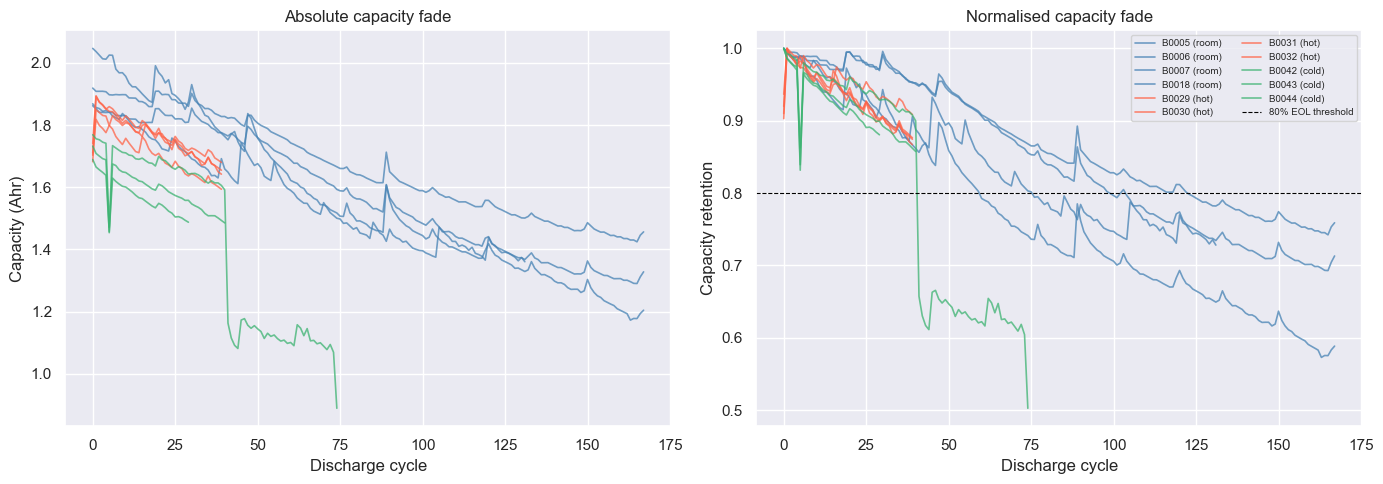

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"room": "steelblue", "hot": "tomato", "cold": "mediumseagreen"}

for ax, col, ylabel, title in [
    (axes[0], "capacity_ahr",       "Capacity (Ahr)",     "Absolute capacity fade"),
    (axes[1], "capacity_retention", "Capacity retention", "Normalised capacity fade"),
]:
    for battery_id, grp in controlled.groupby("battery_id"):
        tc = grp["temp_condition"].iloc[0]
        ax.plot(grp["cycle_index"], grp[col],
                color=palette[tc], alpha=0.75, linewidth=1.2, label=f"{battery_id} ({tc})")
    if col == "capacity_retention":
        ax.axhline(0.8, color="black", linestyle="--", linewidth=0.8, label="80% EOL threshold")
    ax.set(xlabel="Discharge cycle", ylabel=ylabel, title=title)

# Deduplicated legend on the right plot
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig(RESULTS / "controlled_capacity_fade.png", dpi=150)
plt.show()

## 6. Temperature effect — mean capacity fade per condition

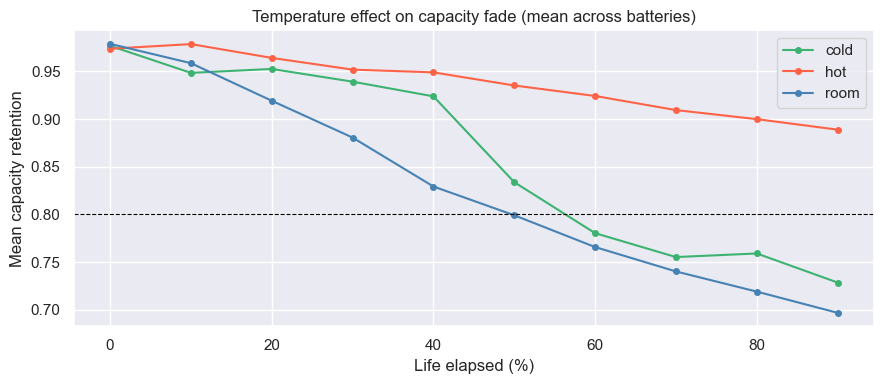

In [8]:
# Bin cycles into deciles so batteries with different lifespans are comparable
controlled["cycle_pct"] = controlled.groupby("battery_id")["rul"].transform(lambda s: 1 - s)
controlled["decile"] = pd.cut(controlled["cycle_pct"], bins=10, labels=False)

mean_fade = (
    controlled.groupby(["temp_condition", "decile"])["capacity_retention"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
for tc, grp in mean_fade.groupby("temp_condition"):
    ax.plot(grp["decile"] * 10, grp["capacity_retention"],
            marker="o", markersize=4, label=tc, color=palette[tc])

ax.axhline(0.8, color="black", linestyle="--", linewidth=0.8)
ax.set(xlabel="Life elapsed (%)", ylabel="Mean capacity retention",
       title="Temperature effect on capacity fade (mean across batteries)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "temperature_effect.png", dpi=150)
plt.show()

## 7. Randomized — capacity fade by load condition

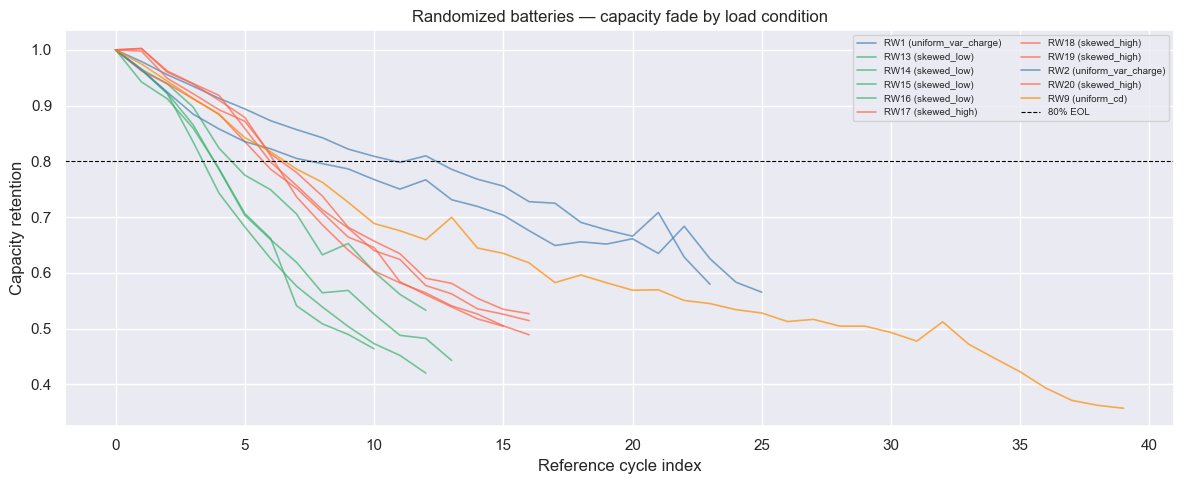

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
rw_palette = {
    "uniform_var_charge": "steelblue",
    "uniform_cd":         "darkorange",
    "skewed_low":         "mediumseagreen",
    "skewed_high":        "tomato",
}

for battery_id, grp in randomized.groupby("battery_id"):
    cond = grp["rw_condition"].iloc[0]
    ax.plot(grp["cycle_index"], grp["capacity_retention"],
            color=rw_palette[cond], alpha=0.7, linewidth=1.2, label=f"{battery_id} ({cond})")

ax.axhline(0.8, color="black", linestyle="--", linewidth=0.8, label="80% EOL")
ax.set(xlabel="Reference cycle index", ylabel="Capacity retention",
       title="Randomized batteries — capacity fade by load condition")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "rw_capacity_fade.png", dpi=150)
plt.show()

## 8. Controlled vs randomized — lifespan comparison

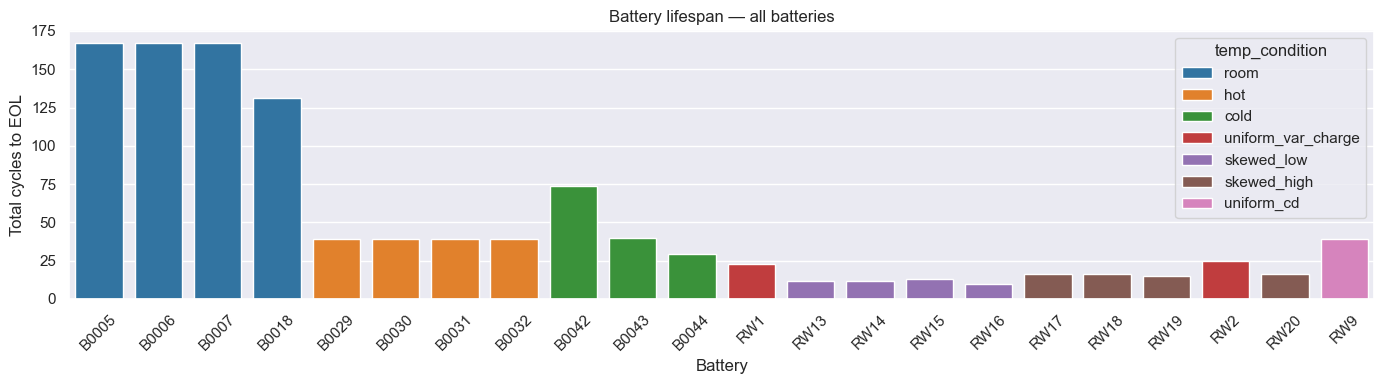

In [10]:
ctrl_life = (
    controlled.groupby("battery_id")["cycle_index"].max()
    .reset_index()
    .rename(columns={"cycle_index": "total_cycles"})
    .merge(controlled[["battery_id", "temp_condition"]].drop_duplicates())
    .assign(dataset="controlled")
)

rw_life = (
    randomized.groupby("battery_id")["cycle_index"].max()
    .reset_index()
    .rename(columns={"cycle_index": "total_cycles"})
    .merge(randomized[["battery_id", "rw_condition"]].drop_duplicates())
    .rename(columns={"rw_condition": "temp_condition"})
    .assign(dataset="randomized")
)

life_df = pd.concat([ctrl_life, rw_life], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=life_df, x="battery_id", y="total_cycles",
            hue="temp_condition", dodge=False, ax=ax)
ax.set(xlabel="Battery", ylabel="Total cycles to EOL",
       title="Battery lifespan — all batteries")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(RESULTS / "lifespan_comparison.png", dpi=150)
plt.show()

## 9. Correlation heatmap — controlled cycle features

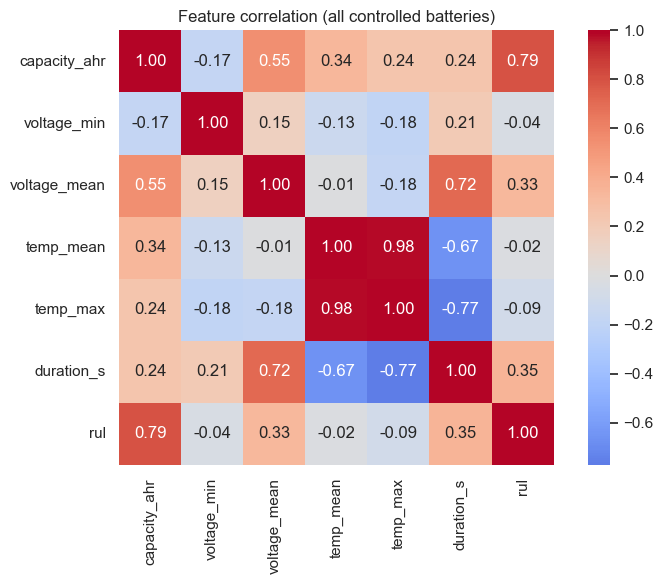

In [11]:
feature_cols = ["capacity_ahr", "voltage_min", "voltage_mean",
                "temp_mean", "temp_max", "duration_s", "rul"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    controlled[feature_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax
)
ax.set_title("Feature correlation (all controlled batteries)")
plt.tight_layout()
plt.savefig(RESULTS / "correlation_heatmap.png", dpi=150)
plt.show()

## 10. Summary statistics

In [12]:
print("=== Controlled ===")
display(controlled.groupby(["battery_id", "temp_condition"])[feature_cols].mean().round(3))

print("\n=== Randomized ===")
rw_features = ["capacity_ahr", "voltage_min", "voltage_mean", "temp_mean", "duration_s", "rul"]
display(randomized.groupby(["battery_id", "rw_condition"])[rw_features].mean().round(3))

=== Controlled ===


,,capacity_ahr,voltage_min,voltage_mean,temp_mean,temp_max,duration_s,rul
battery_id,temp_condition,,,,,,,
B0005,room,1.576,2.649,3.517,32.791,39.845,3129.524,0.5
B0006,room,1.561,2.416,3.464,32.793,39.869,3129.524,0.5
B0007,room,1.666,2.080,3.518,32.368,40.440,3129.524,0.5
B0018,room,1.571,2.412,3.496,31.094,37.738,3069.074,0.5
B0029,hot,1.767,1.903,3.395,52.800,59.964,1616.300,0.5
B0030,hot,1.699,2.085,3.384,54.245,62.482,1616.300,0.5
B0031,hot,1.762,2.401,3.417,53.736,61.737,1616.300,0.5
B0032,hot,1.759,2.647,3.351,54.343,61.792,1616.300,0.5
B0042,cold,1.419,2.147,3.097,27.518,37.719,2108.656,0.5



=== Randomized ===


,,capacity_ahr,voltage_min,voltage_mean,temp_mean,duration_s,rul
battery_id,rw_condition,,,,,,
RW1,uniform_var_charge,1.600,3.2,3.632,25.880,5760.972,0.5
RW13,skewed_low,1.611,3.2,3.660,23.550,5799.556,0.5
RW14,skewed_low,1.421,3.2,3.638,23.189,5117.138,0.5
RW15,skewed_low,1.452,3.2,3.643,23.666,5226.891,0.5
RW16,skewed_low,1.512,3.2,3.653,23.417,5445.644,0.5
RW17,skewed_high,1.581,3.2,3.662,25.029,5691.132,0.5
RW18,skewed_high,1.587,3.2,3.666,23.737,5714.318,0.5
RW19,skewed_high,1.572,3.2,3.666,25.207,5658.117,0.5
RW2,uniform_var_charge,1.490,3.2,3.620,NaN,5364.895,0.5


## 11. Resistance proxy validation against EIS (controlled batteries)

**The field-realistic proxy:** in real renewable-energy installations, batteries rarely sit at full rest — EIS sweeps are impractical. We define a **DCIR onset proxy**:

```
R_proxy = (V_rest − V_loaded) / |I_load|
```

where V_rest is the open-circuit voltage at the very start of a discharge and V_loaded is the median voltage once current is established. This is computable from ordinary telemetry, with no dedicated test.

**Validation:** on controlled batteries (which *do* have EIS), we correlate R_proxy with the true `Rct` from EIS to quantify how much information the proxy captures.  
A correlation ≥ 0.70 is sufficient to justify using the proxy as the primary resistance feature for the randomized (renewable-proxy) batteries.

Onset DCIR proxy vs EIS (room-temp controlled batteries)


,n_cycles,corr_Rct,corr_Re,proxy_first,proxy_last,Rct_first,Rct_last
battery_id,,,,,,,
B0005,168,0.684,0.559,0.165,0.168,0.069,0.075
B0006,168,0.948,0.941,0.158,0.199,0.079,0.100
B0007,168,0.466,0.409,0.163,0.158,0.062,0.093
B0018,132,0.603,0.817,0.147,0.179,0.096,0.089


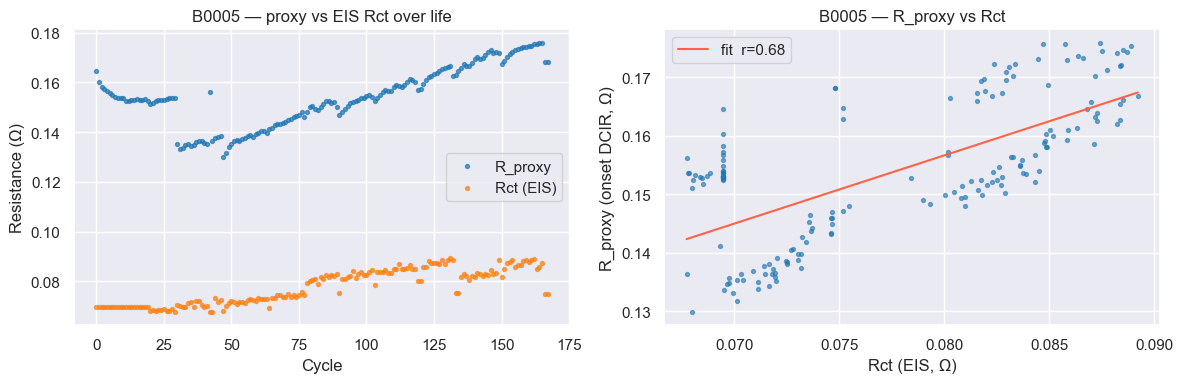

In [13]:
G1 = CTRL / "1. BatteryAgingARC-FY08Q4"
G3 = CTRL / "3. BatteryAgingARC_25-44"

_eis_rows = []
for bat_id, path in [
    ("B0005", G1 / "B0005.mat"),
    ("B0006", G1 / "B0006.mat"),
    ("B0007", G1 / "B0007.mat"),
    ("B0018", G1 / "B0018.mat"),
]:
    cycles_raw = load_controlled(path)
    df_ctrl    = cycles_to_df(cycles_raw, bat_id, None, "room")
    imp_df     = load_impedance(path)
    df_joined  = attach_impedance(df_ctrl, imp_df)
    corr_rct   = df_joined["r_proxy"].corr(df_joined["Rct"])
    corr_re    = df_joined["r_proxy"].corr(df_joined["Re"])
    _eis_rows.append({
        "battery_id":  bat_id,
        "n_cycles":    len(df_joined),
        "corr_Rct":    corr_rct,
        "corr_Re":     corr_re,
        "proxy_first": df_joined["r_proxy"].iloc[0],
        "proxy_last":  df_joined["r_proxy"].iloc[-1],
        "Rct_first":   df_joined["Rct"].iloc[0],
        "Rct_last":    df_joined["Rct"].iloc[-1],
    })

eis_summary = pd.DataFrame(_eis_rows).set_index("battery_id").round(3)
print("Onset DCIR proxy vs EIS (room-temp controlled batteries)")
display(eis_summary)

# Scatter plot for B0005 (most cycles)
df_b5 = attach_impedance(
    cycles_to_df(load_controlled(G1 / "B0005.mat"), "B0005", 2.7, "room"),
    load_impedance(G1 / "B0005.mat"),
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_b5["cycle_index"], df_b5["r_proxy"], s=8, label="R_proxy", alpha=0.7)
axes[0].scatter(df_b5["cycle_index"], df_b5["Rct"],     s=8, label="Rct (EIS)", alpha=0.7)
axes[0].set(xlabel="Cycle", ylabel="Resistance (Ω)", title="B0005 — proxy vs EIS Rct over life")
axes[0].legend()

axes[1].scatter(df_b5["Rct"], df_b5["r_proxy"], s=8, alpha=0.6)
m, b = np.polyfit(df_b5["Rct"], df_b5["r_proxy"], 1)
x_line = np.linspace(df_b5["Rct"].min(), df_b5["Rct"].max(), 100)
axes[1].plot(x_line, m * x_line + b, color="tomato", linewidth=1.5,
             label=f"fit  r={df_b5['r_proxy'].corr(df_b5['Rct']):.2f}")
axes[1].set(xlabel="Rct (EIS, Ω)", ylabel="R_proxy (onset DCIR, Ω)",
            title="B0005 — R_proxy vs Rct")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / "proxy_vs_eis.png", dpi=150)
plt.show()


## 12. Correlation heatmap — randomized cycle features

Mirrors §9 for the RW dataset. `voltage_min` is excluded (constant 3.2 V floor). `r_proxy` is included — it is the only resistance-like feature available in the field-realistic regime.

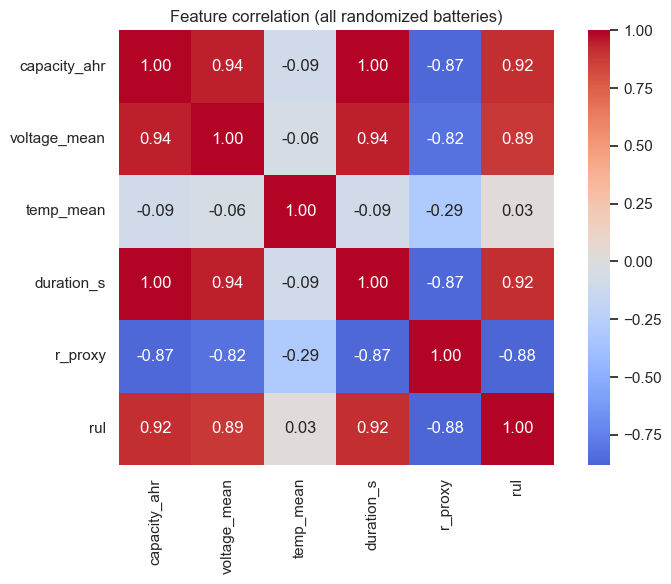

In [14]:
rw_feature_cols = ["capacity_ahr", "voltage_mean", "temp_mean", "duration_s",
                   "r_proxy", "rul"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    randomized[rw_feature_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax
)
ax.set_title("Feature correlation (all randomized batteries)")
plt.tight_layout()
plt.savefig(RESULTS / "rw_correlation_heatmap.png", dpi=150)
plt.show()
